# Phase 6 — GARCH Volatility Scaling
Runs the GARCH module and displays results. All logic lives in `src/volatility/garch.py`, this notebook only calls it and shows the charts.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from src.data_collection import config
from src.data_collection.saver import save_processed
from src.volatility.garch import (
    fit_garch_model, get_conditional_volatility, forecast_volatility,
    get_standardized_residuals, garch_scaled_returns, garch_scaled_historical_var,
)
from src.var.historical import calculate_historical_var
from src.visualization import garch_charts
from src.visualization import charts

## Load Phase 3 output (portfolio returns)

In [2]:
portfolio_returns = pd.read_csv(
    config.DATA_PROCESSED_DIR / 'portfolio_returns_phase3.csv',
    index_col=0, parse_dates=True
).iloc[:, 0]
portfolio_returns.tail()

date
2026-07-16   -0.015001
2026-07-17   -0.014545
2026-07-20    0.001204
2026-07-21    0.011876
2026-07-22    0.006389
Name: portfolio_return, dtype: float64

## Fit GARCH(1,1)

In [3]:
fitted_model = fit_garch_model(portfolio_returns, p=1, q=1)
print(fitted_model.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:       portfolio_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2456.18
Distribution:                  Normal   AIC:                           4920.37
Method:            Maximum Likelihood   BIC:                           4941.32
                                        No. Observations:                 1393
Date:                Wed, Aug 26 2026   Df Residuals:                     1392
Time:                        18:11:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1467  3.544e-02      4.140  3.470e-05 [7.726e-0

In [4]:
conditional_vol = get_conditional_volatility(fitted_model)
conditional_vol.tail()

date
2026-07-16    0.013393
2026-07-17    0.013694
2026-07-20    0.013920
2026-07-21    0.013416
2026-07-22    0.013257
Name: garch_conditional_volatility, dtype: float64

In [5]:
forecast = forecast_volatility(fitted_model, horizon=10)
forecast

1     0.012868
2     0.012927
3     0.012985
4     0.013041
5     0.013095
6     0.013148
7     0.013200
8     0.013250
9     0.013299
10    0.013347
Name: garch_forecast_volatility, dtype: float64

In [6]:
residuals = get_standardized_residuals(fitted_model)
print(f'Standardized residual std (should be near 1): {residuals.std():.4f}')

Standardized residual std (should be near 1): 1.0003


## GARCH-scaled VaR

In [7]:
scaled_returns = garch_scaled_returns(portfolio_returns, fitted_model)

hist_var_95 = calculate_historical_var(portfolio_returns, confidence_level=0.95)
garch_var_95 = garch_scaled_historical_var(portfolio_returns, confidence_level=0.95)

print(f'Plain Historical VaR (95%): {hist_var_95:.4f}')
print(f'GARCH-scaled VaR (95%):     {garch_var_95:.4f}')

Plain Historical VaR (95%): 0.0238
GARCH-scaled VaR (95%):     0.0208


## Charts

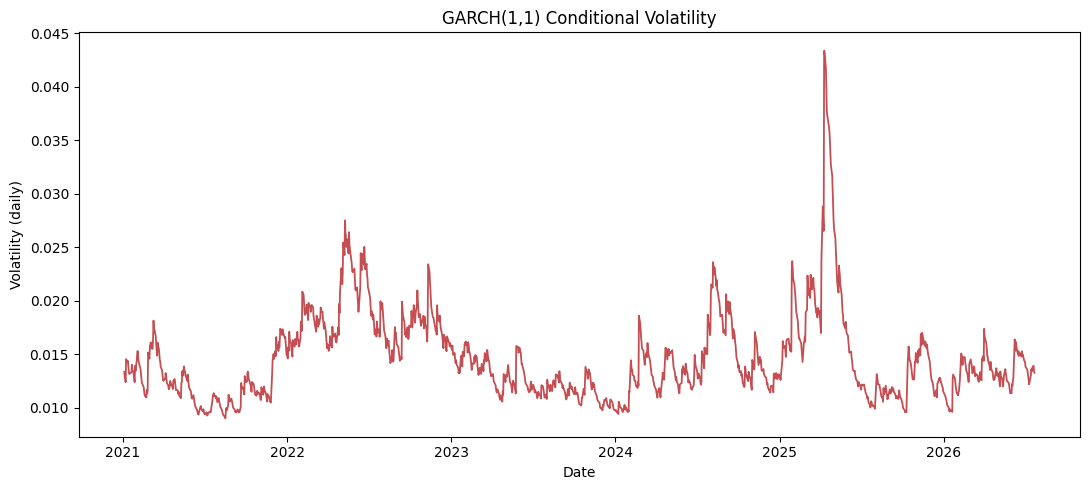

In [8]:
fig1 = garch_charts.plot_garch_conditional_volatility(conditional_vol)
plt.show()

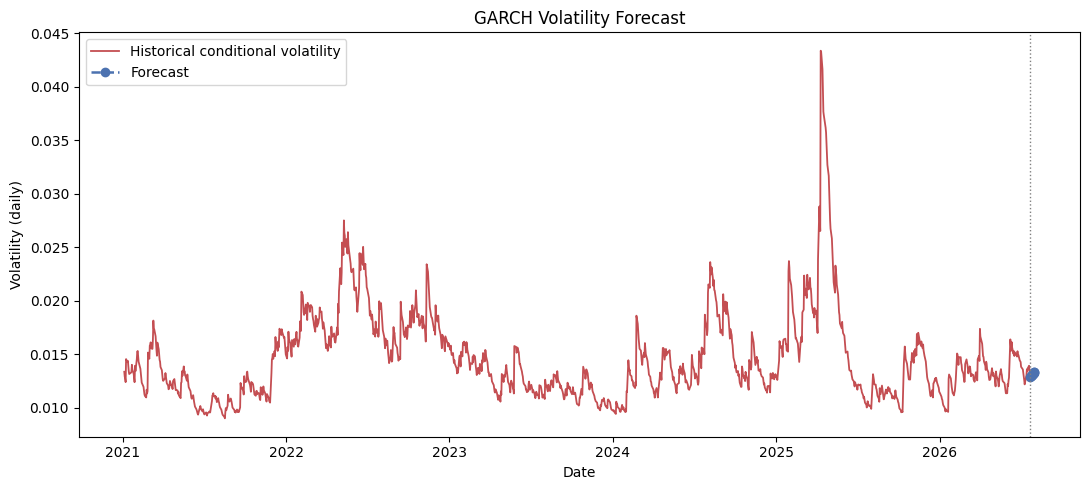

In [9]:
fig2 = garch_charts.plot_garch_forecast(conditional_vol, forecast)
plt.show()

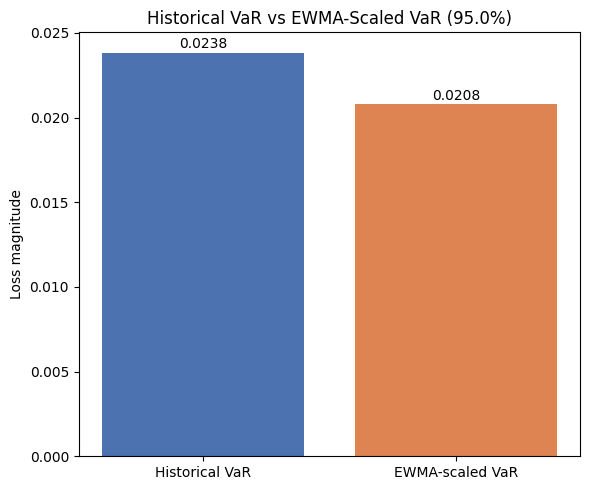

In [10]:
fig3 = charts.plot_var_comparison(hist_var_95, garch_var_95, confidence_level=0.95)
plt.show()

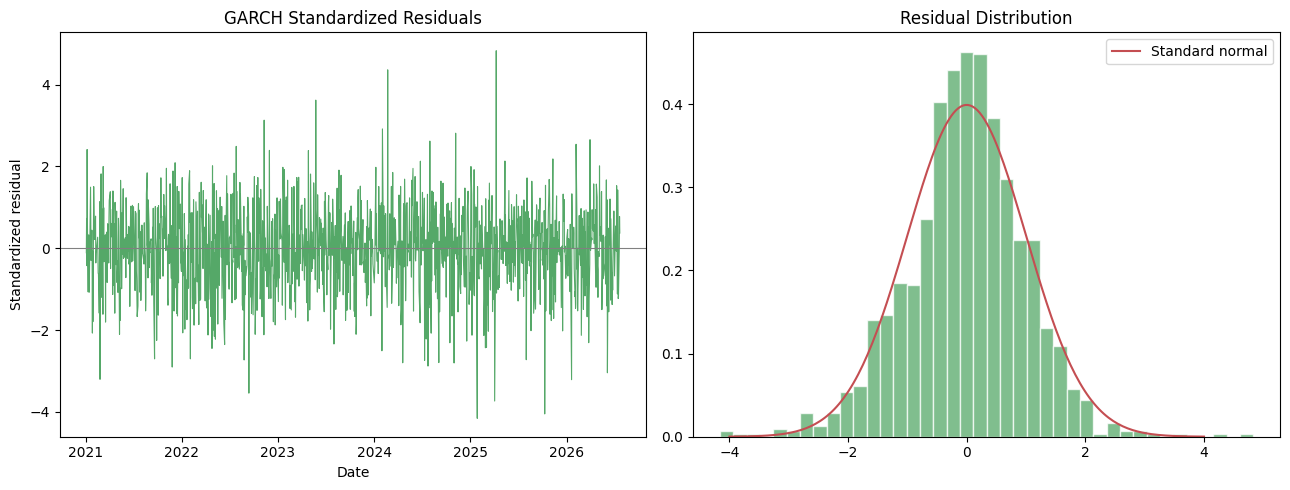

In [11]:
fig4 = garch_charts.plot_standardized_residuals(residuals)
plt.show()

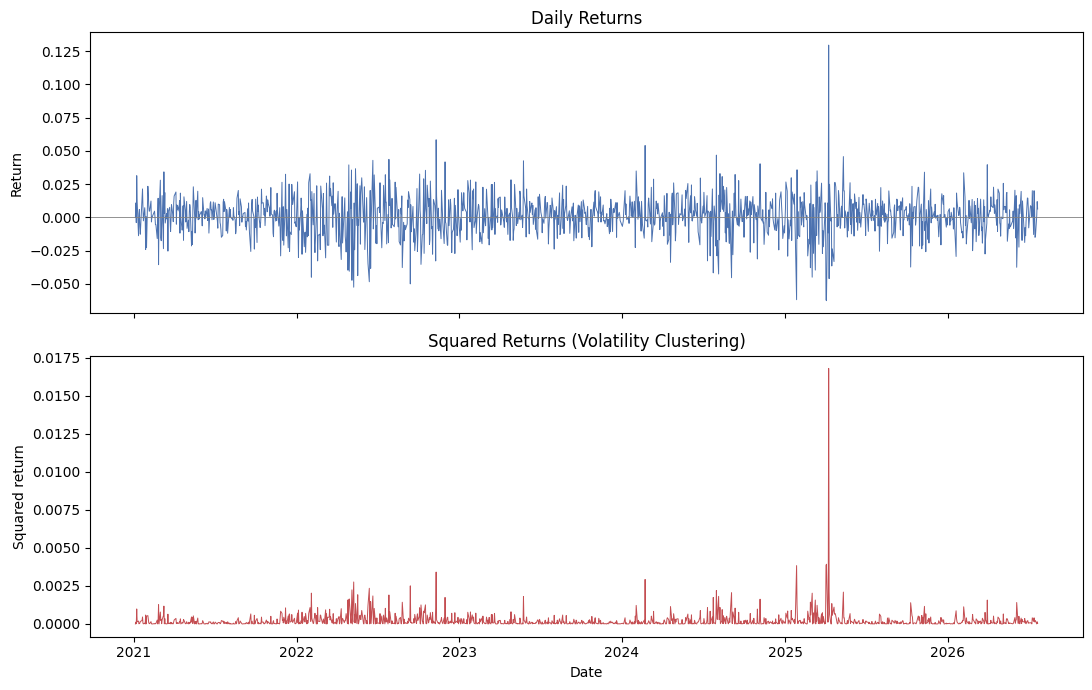

In [12]:
fig5 = garch_charts.plot_volatility_clustering(portfolio_returns)
plt.show()

## Save Phase 6 outputs

In [13]:
save_processed(conditional_vol.to_frame(), 'garch_conditional_volatility.csv', config.DATA_PROCESSED_DIR)
save_processed(forecast.to_frame(), 'garch_volatility_forecast.csv', config.DATA_PROCESSED_DIR)
save_processed(scaled_returns.to_frame(), 'garch_scaled_returns.csv', config.DATA_PROCESSED_DIR)
save_processed(residuals.to_frame(), 'garch_standardized_residuals.csv', config.DATA_PROCESSED_DIR)
print('Phase 6 outputs saved.')

Phase 6 outputs saved.
